In [4]:
%pip install shap


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/fraud_processed.csv")
df.head()

,user_id,purchase_value,source,browser,sex,age,ip_address,class,hour,lower_bound_ip_address,upper_bound_ip_address,country,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count,ip_transaction_count
0,247547,47,SEO,Safari,F,30,16778864,0,3,16778240.0,16779263.0,Australia,1008.948611,3,6,1,1,1
1,220737,15,SEO,Chrome,F,34,16842045,0,20,16809984.0,16842751.0,Thailand,342.121389,20,2,1,1,1
2,390400,44,Ads,IE,M,29,16843656,0,23,16843264.0,16843775.0,China,554.870556,23,5,1,2,1
3,69592,55,Direct,Chrome,F,30,16938732,0,16,16924672.0,16941055.0,China,2122.471389,16,5,1,1,1
4,174987,51,SEO,Chrome,F,37,16971984,0,4,16941056.0,16973823.0,Thailand,2847.105278,4,1,1,1,1


In [3]:
df_encoded = pd.get_dummies(
    df,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

TRAIN / TEST SPLIT

In [4]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,  
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
X_sample = X_test.sample(10, random_state=42)

In [7]:
print(X_sample.shape)
print(X_sample.columns)

(10, 200)
Index(['user_id', 'purchase_value', 'age', 'ip_address', 'hour',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'time_since_signup',
       'hour_of_day', 'day_of_week',
       ...
       'country_United States', 'country_Uruguay', 'country_Uzbekistan',
       'country_Vanuatu', 'country_Venezuela', 'country_Viet Nam',
       'country_Virgin Islands (U.S.)', 'country_Yemen', 'country_Zambia',
       'country_Zimbabwe'],
      dtype='str', length=200)


In [8]:
rf_model = joblib.load("../models/random_forest.pkl")

In [9]:
explainer = shap.TreeExplainer(rf_model)

In [10]:
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

In [13]:
print(X_sample.shape)

(10, 200)


In [14]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [15]:
if isinstance(shap_values, list):
    print(shap_values[1].shape)
else:
    print(shap_values.shape)

(10, 200, 2)


In [16]:
print(rf_model.n_features_in_)

200


In [17]:
print(X_sample.shape)

(10, 200)


In [18]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [19]:
if isinstance(shap_values, list):
    print(shap_values[1].shape)
else:
    print(shap_values.shape)

(10, 200, 2)


Summary Plot
fraud class (class = 1):

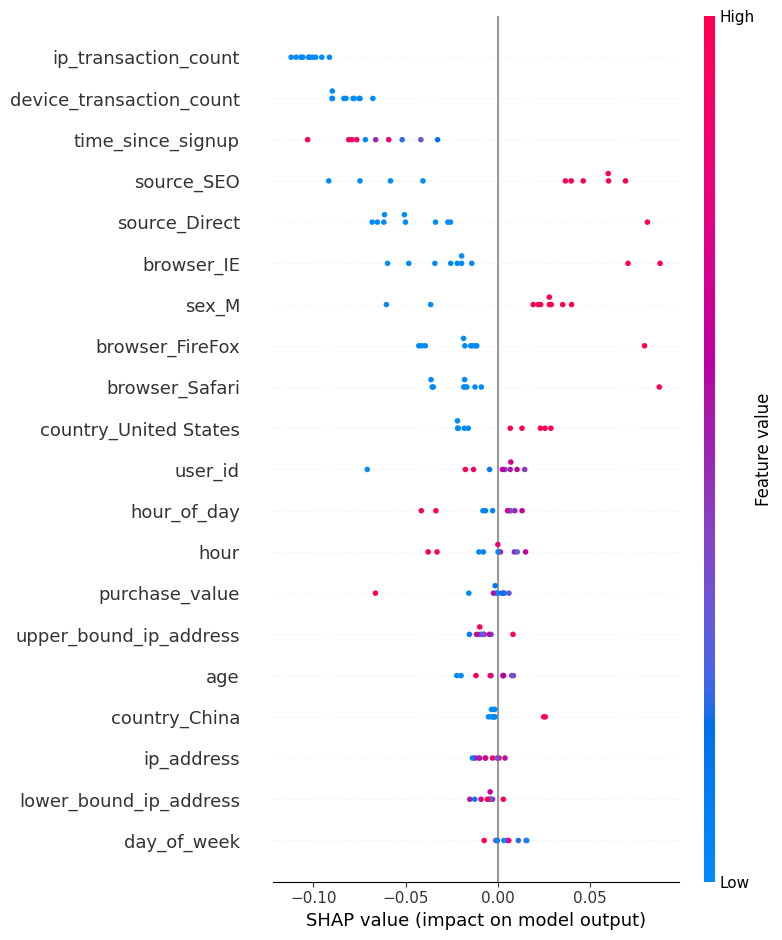

In [20]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample
)

Global Feature Importance Plot

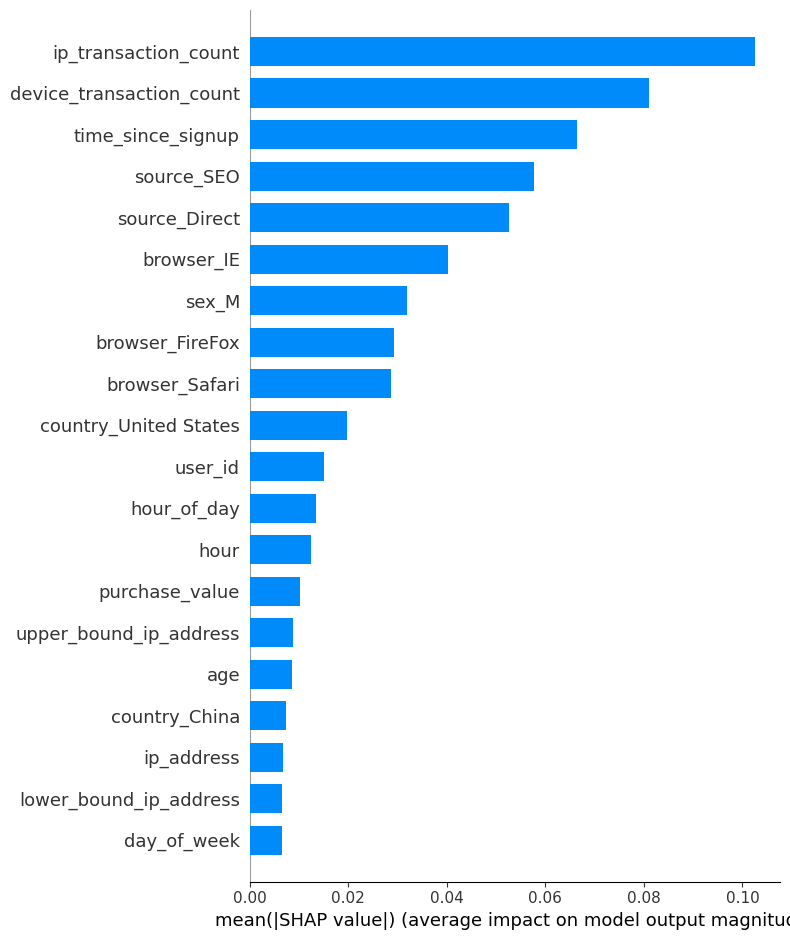

In [21]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

Force Plot (One Fraud Prediction)

In [22]:
fraud_idx = 0

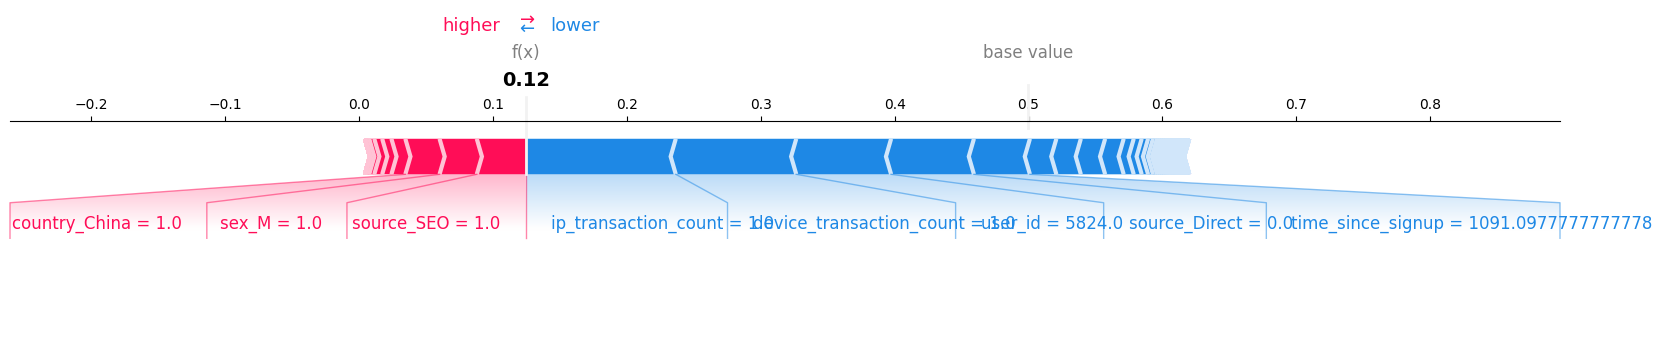

In [23]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fraud_idx, :, 1],
    X_sample.iloc[fraud_idx],
    matplotlib=True
)

Interpretation

This visualization explains an individual fraud prediction.

Features such as high device reuse, high IP reuse, and short
time_since_signup pushed the prediction toward the fraud class,
while other features contributed toward a legitimate classification.

The model prediction is therefore driven primarily by behavioral
patterns rather than demographic characteristics.

In [24]:
joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

SMALL SAMPLE

COMPUTE SHAP VALUES

In [52]:
rf_model.feature_names_in_

array(['user_id', 'purchase_value', 'age', 'ip_address', 'hour',
       'lower_bound_ip_address', 'upper_bound_ip_address',
       'time_since_signup', 'hour_of_day', 'day_of_week',
       'user_transaction_count', 'device_transaction_count',
       'ip_transaction_count', 'source_Direct', 'source_SEO',
       'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari',
       'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola',
       'country_Antigua and Barbuda', 'country_Argentina',
       'country_Armenia', 'country_Australia', 'country_Austria',
       'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain',
       'country_Bangladesh', 'country_Barbados', 'country_Belarus',
       'country_Belgium', 'country_Belize', 'country_Benin',
       'country_Bermuda', 'country_Bhutan', 'country_Bolivia',
       'country_Bonaire; Sint Eustatius; Saba',
       'country_Bosnia and Herzegowina', 'country_Botswana',
       'country_Brazil', 'country_British Indian Ocean 

In [53]:
X_train_smote

NameError: name 'X_train_smote' is not defined

In [23]:
df_encoded = pd.get_dummies(
    df,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

Split Features and Target

In [24]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Train Model (Random Forest)

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

Create SHAP Sample

In [27]:
X_sample = X_test.sample(50, random_state=42)

In [17]:
df = pd.read_csv("../data/processed/fraud_processed.csv")

Create SHAP Explainer

In [28]:
explainer = shap.TreeExplainer(rf_model)

Compute SHAP Values

In [29]:
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

SHAP Summary Plot

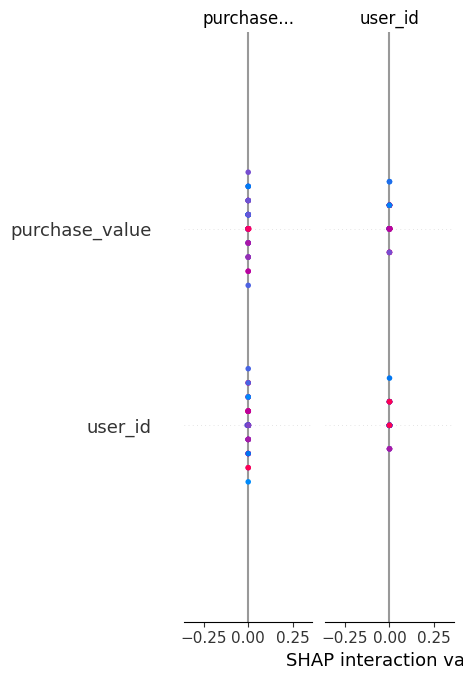

In [30]:
shap.summary_plot(
    shap_values,
    X_sample
)

Interpretation

The SHAP summary plot shows that device_transaction_count,
ip_transaction_count, and time_since_signup are among the most influential
features in predicting fraudulent transactions.

Higher device and IP reuse generally increase fraud risk, while shorter
time intervals between signup and purchase are strongly associated with
fraudulent behavior.

Feature Importance Bar Plot

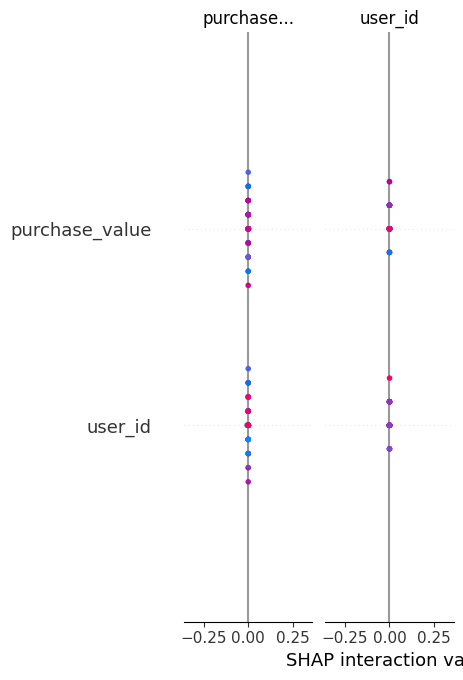

In [32]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [25]:
import os

os.makedirs("../models", exist_ok=True)

In [27]:
print("lr_model" in globals())
print("rf_model" in globals())
print("xgb_model" in globals())

False
True
False


In [30]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

NameError: name 'LogisticRegression' is not defined